# QAR Baseline vs OpenAP/BADA Fuel-Optimal Trajectories

This notebook reproduces the comparison plot from `debug/qar_baseline_comparison` using the cached QAR baseline and optimized OpenAP, BADA 3, and BADA 4 trajectories.

In [1]:
from pathlib import Path

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt

import pandas as pd


def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for path in (cwd, *cwd.parents):
        if (path / "opentop").is_dir() and (path / "examples").is_dir():
            return path
    raise RuntimeError("Run this notebook from the opentop repository.")


ROOT = find_repo_root()
DEBUG_DIR = ROOT / "debug" / "qar_baseline_comparison"
FIGURE_PATH = DEBUG_DIR / "optimization_vs_qar_distance.png"

DEBUG_DIR

PosixPath('/home/junzi/arc/code/1-public/opentop/debug/qar_baseline_comparison')

In [2]:
qar = pd.read_csv(DEBUG_DIR / "qar_fixed_trajectory.csv")

trajectories = {
    "openap": pd.read_csv(DEBUG_DIR / "optimized_openap.csv"),
    "bada3": pd.read_csv(DEBUG_DIR / "optimized_bada3.csv"),
    "bada4": pd.read_csv(DEBUG_DIR / "optimized_bada4_operational_guard.csv"),
}

colors = {
    "qar_reference": "tab:green",
    "openap": "tab:blue",
    "bada3": "tab:orange",
    "bada4": "tab:red",
}

summary_rows = [
    {
        "trajectory": "qar_reference",
        "solver_success": True,
        "solver_status": "assumed_optimal_reference",
        "fuel_kg": float(qar.mass.iloc[0] - qar.mass.iloc[-1]),
        "time_s": float(qar.ts.iloc[-1] - qar.ts.iloc[0]),
        "max_altitude_ft": float(qar.altitude.max()),
        "mean_mach": float(qar.mach.mean()),
        "distance_km": float(qar.distance_km.iloc[-1] - qar.distance_km.iloc[0]),
        "source": "QAR mass delta",
    }
]

for name, df in trajectories.items():
    summary_rows.append(
        {
            "trajectory": name,
            "solver_success": bool(df.solver_success.iloc[0])
            if "solver_success" in df
            else True,
            "solver_status": str(df.solver_status.iloc[0])
            if "solver_status" in df
            else "",
            "fuel_kg": float(df.mass.iloc[0] - df.mass.iloc[-1]),
            "time_s": float(df.ts.iloc[-1] - df.ts.iloc[0]),
            "max_altitude_ft": float(df.altitude.max()),
            "mean_mach": float(df.mach.mean()),
            "distance_km": float(df.distance_km.iloc[-1] - df.distance_km.iloc[0]),
            "source": "optimized",
        }
    )

summary = pd.DataFrame(summary_rows)
summary

,trajectory,solver_success,solver_status,fuel_kg,time_s,max_altitude_ft,mean_mach,distance_km,source
0,qar_reference,True,assumed_optimal_reference,5655.837685,6929.0000,33023.546875,0.734955,1634.174421,QAR mass delta
1,openap,True,Solve_Succeeded,5570.884751,7597.1476,38001.000000,0.697897,1632.433172,optimized
2,bada3,False,Maximum_Iterations_Exceeded,5532.011224,8906.8390,31340.000000,0.585564,1632.433172,optimized
3,bada4,True,Solve_Succeeded,5035.760626,8348.0577,33435.000000,0.633480,1632.345814,optimized


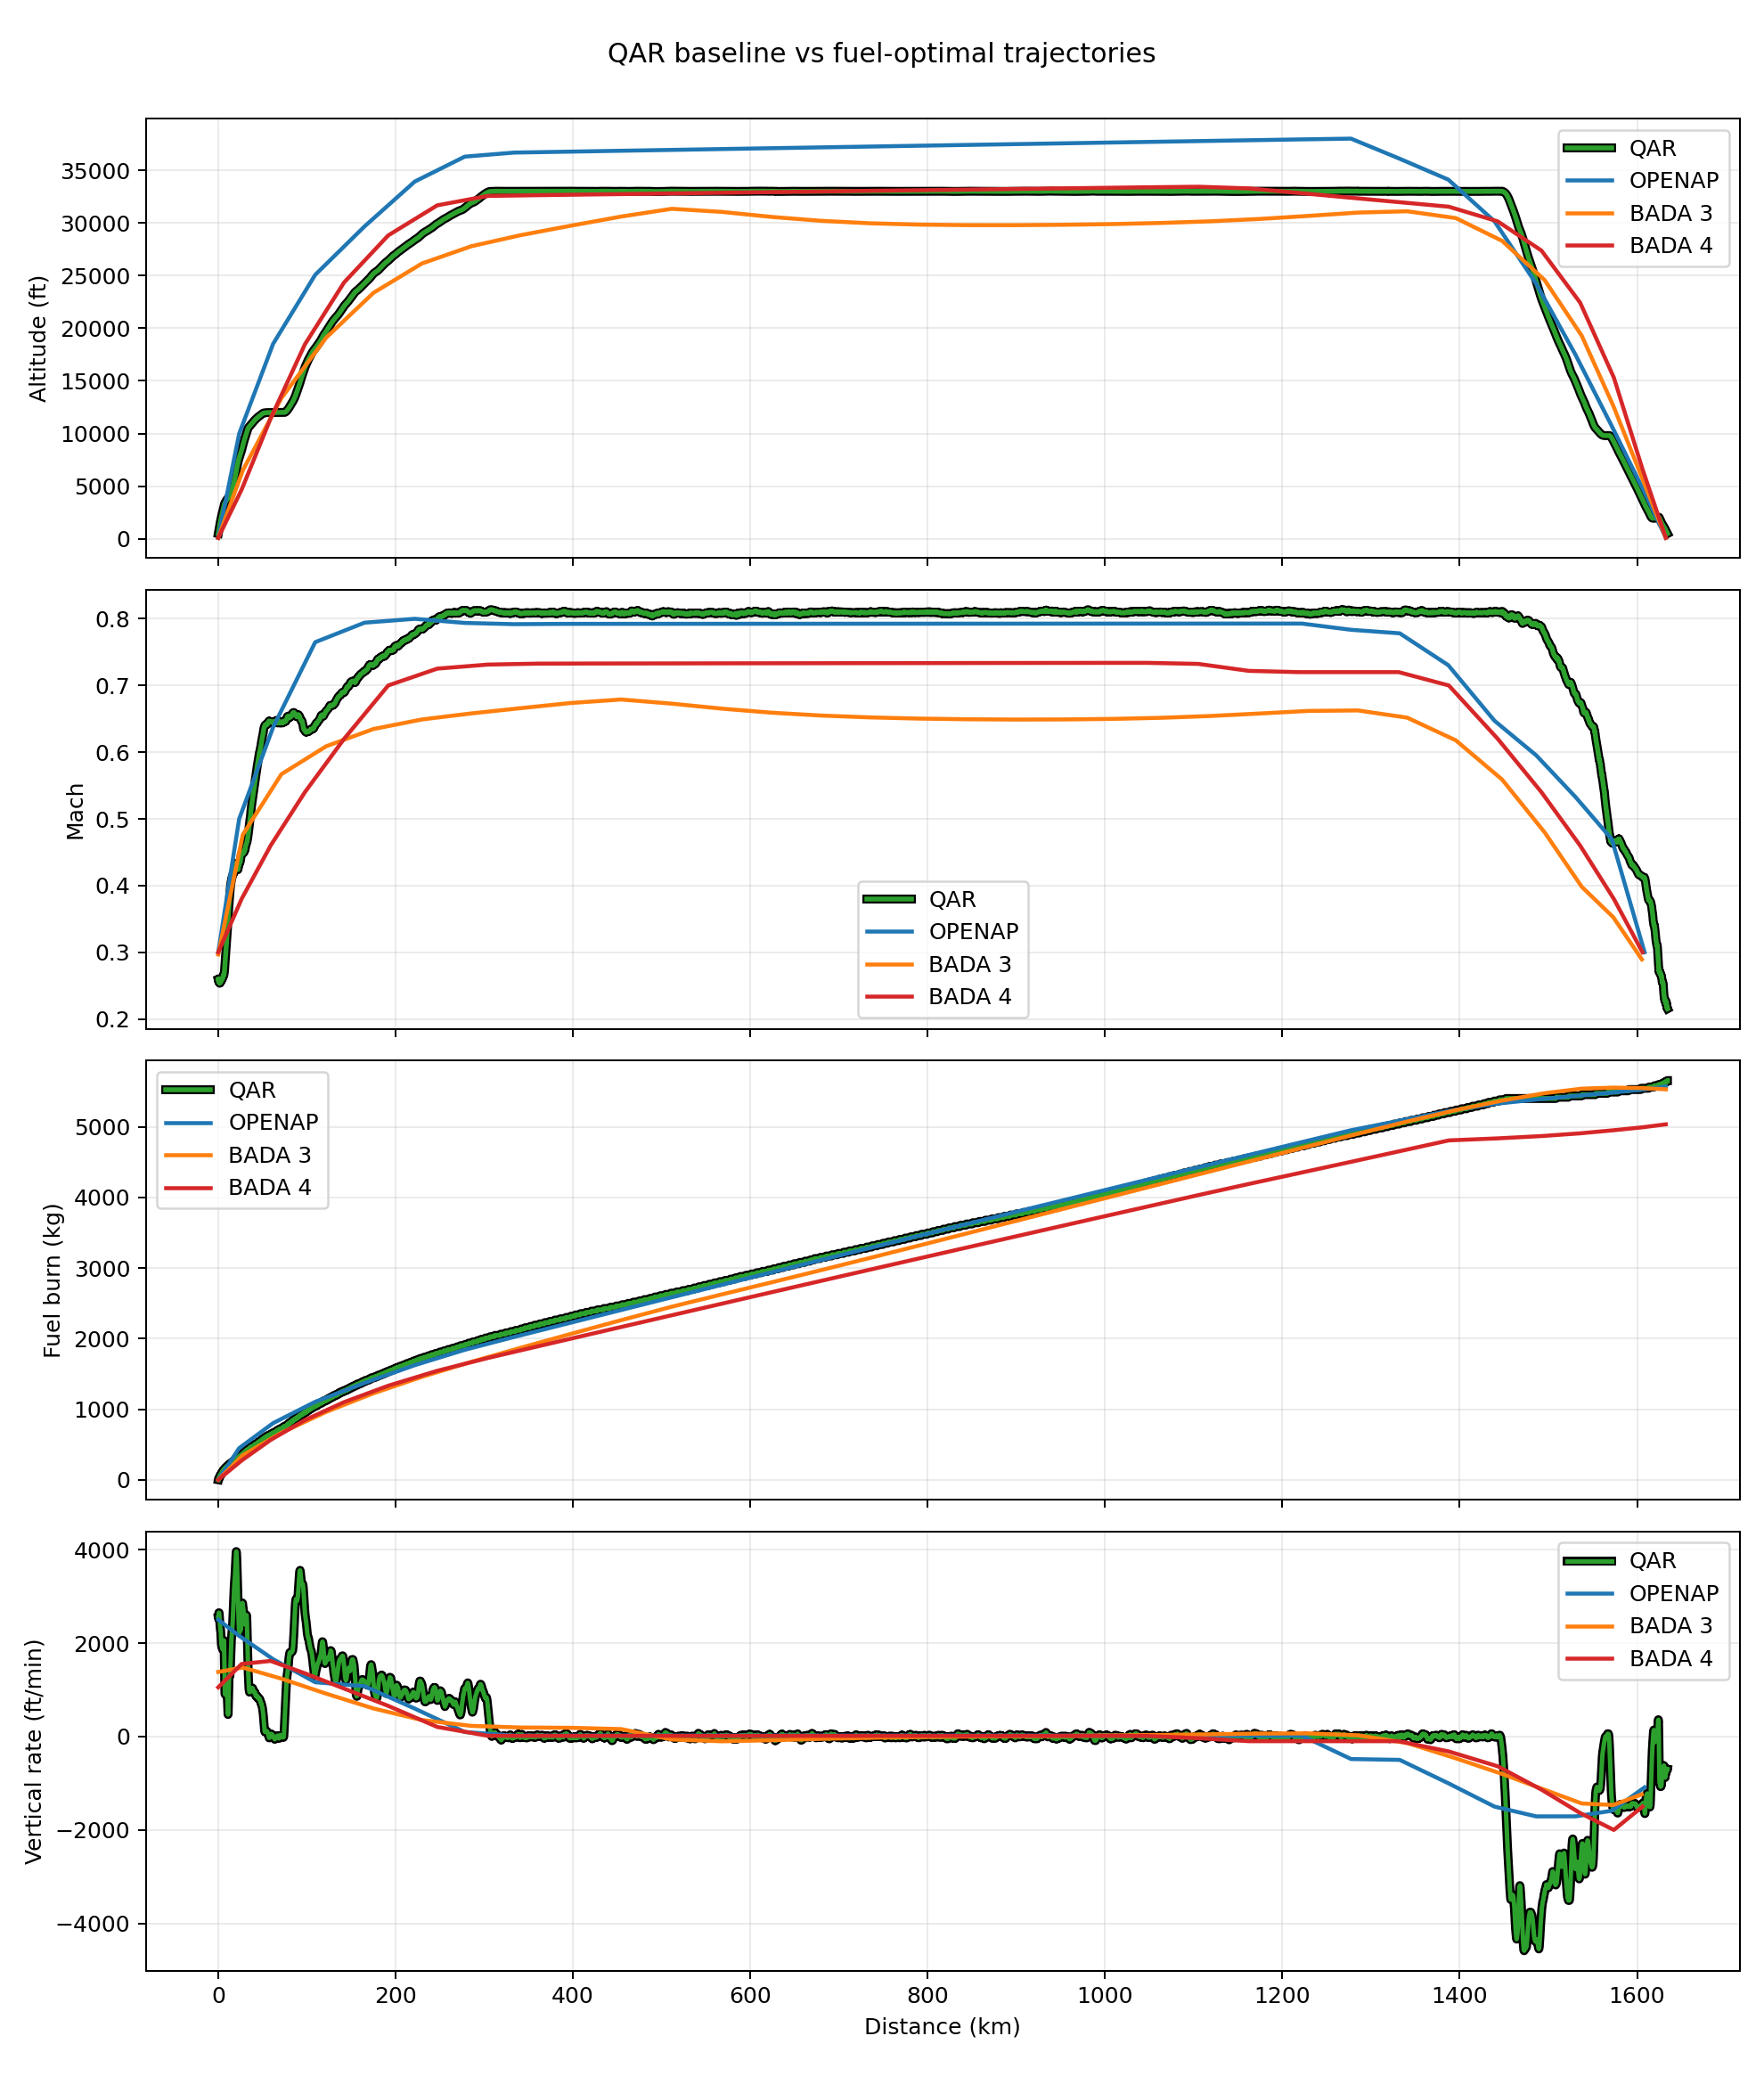

In [3]:
def plot_profiles(save_path: Path | None = None):
    qar_effect = [pe.Stroke(linewidth=4.0, foreground="black"), pe.Normal()]
    fig, axes = plt.subplots(4, 1, figsize=(11, 13), sharex=True)

    qar_lines = [
        axes[0].plot(
            qar.distance_km,
            qar.altitude,
            color=colors["qar_reference"],
            lw=2.2,
            label="QAR",
        )[0],
        axes[1].plot(
            qar.distance_km,
            qar.mach,
            color=colors["qar_reference"],
            lw=2.2,
            label="QAR",
        )[0],
        axes[2].plot(
            qar.distance_km,
            qar.mass.iloc[0] - qar.mass,
            color=colors["qar_reference"],
            lw=2.2,
            label="QAR",
        )[0],
        axes[3].plot(
            qar.distance_km,
            qar.vertical_rate,
            color=colors["qar_reference"],
            lw=2.0,
            label="QAR",
        )[0],
    ]
    for line in qar_lines:
        line.set_path_effects(qar_effect)

    for name, df in trajectories.items():
        label = (
            name.upper() if name == "openap" else name.upper().replace("BADA", "BADA ")
        )
        ctrl = df.iloc[:-1]
        axes[0].plot(
            df.distance_km, df.altitude, color=colors[name], lw=1.8, label=label
        )
        axes[1].plot(
            ctrl.distance_km, ctrl.mach, color=colors[name], lw=1.8, label=label
        )
        axes[2].plot(
            df.distance_km,
            df.mass.iloc[0] - df.mass,
            color=colors[name],
            lw=1.8,
            label=label,
        )
        axes[3].plot(
            ctrl.distance_km,
            ctrl.vertical_rate,
            color=colors[name],
            lw=1.8,
            label=label,
        )

    axes[0].set_ylabel("Altitude (ft)")
    axes[1].set_ylabel("Mach")
    axes[2].set_ylabel("Fuel burn (kg)")
    axes[3].set_ylabel("Vertical rate (ft/min)")
    axes[3].set_xlabel("Distance (km)")

    for ax in axes:
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best")

    fig.suptitle("QAR baseline vs fuel-optimal trajectories")
    fig.tight_layout(rect=[0, 0.01, 1, 0.98])
    if save_path is not None:
        fig.savefig(save_path, dpi=180)
    return fig, axes


plot_profiles(FIGURE_PATH);

In [4]:
bada4 = trajectories["bada4"]
segment = bada4[(bada4.distance_km >= 950) & (bada4.distance_km <= 1420)]
cruise = bada4[
    (bada4.distance_km >= 500) & (bada4.distance_km <= bada4.distance_km.iloc[-1] - 300)
]

{
    "bada4_segment_mach_min": float(segment.mach.min()),
    "bada4_segment_mach_max": float(segment.mach.max()),
    "bada4_cruise_min_mach": float(cruise.mach.min()),
    "bada4_max_mach_step": float(bada4.mach.diff().abs().dropna().max()),
    "bada4_cruise_vs_below_minus_250_count": int((cruise.vertical_rate < -250).sum()),
}

{'bada4_segment_mach_min': 0.7, 'bada4_segment_mach_max': 0.733893, 'bada4_cruise_min_mach': 0.72, 'bada4_max_mach_step': 0.08000000000000002, 'bada4_cruise_vs_below_minus_250_count': 0}